# Question1

In [17]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ML library
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import linear_model

# Data Balancing Library
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, auc, recall_score,f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

### EDA Steps

In [ ]:
metric_table = pd.DataFrame()
classification_algorithms = {
    'Logistic-Regression': LogisticRegression(multi_class='auto', random_state=42, max_iter=2000),
    'SVC-Linear': SVC(kernel='linear', probability=True, random_state=42),
    'SVC-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'KNeighbors': KNeighborsClassifier()
}


In [23]:
# ...existing code...
# Load the dataset
df = pd.read_csv("image-data-ePGD-endsem.csv")

# Remove rows where any feature column (c1 to c135) is missing (NaN)
feature_cols = [f'c{i}' for i in range(1, 136)]
df = df.dropna(subset=feature_cols)

rows, columns = df.shape
print(f'No. of rows: {rows}')
print(f'No. of columns: {columns}')

# Extract features c1 to c135 and label into a new DataFrame
df_features = df[feature_cols + ['label']].copy()

print("Shape:", df_features.shape)
print(df_features.head(2))
# ...existing code...

No. of rows: 5000
No. of columns: 140
Shape: (5000, 136)
         c1      c2        c3        c4        c5        c6        c7   c8  \
0  0.001067  0.0116  0.038667  0.064400  0.356800  0.499600  0.027867  0.0   
1  0.000133  0.2368  0.419067  0.112267  0.031467  0.083333  0.116933  0.0   

         c9       c10  ...      c127        c128      c129        c130  \
0  0.002267  0.019733  ...  0.181895  108.658800  6.479477  890.007871   
1  0.000000  0.005867  ...  0.362944  110.399333  7.022868  704.594772   

          c131     c132         c133         c134      c135  label  
0  12778.19310  1091397  3573669.586  3101389.448  0.867844      1  
1  10415.92729   849863  3445633.368  1838827.420  0.533669      1  

[2 rows x 136 columns]


In [24]:
# Group image data based on image_filename and get unique set as dictionary

unique_images = df['image_filename'].unique()

# Create a dictionary: key = image_filename, value = DataFrame of rows for that image
image_groups = {img: df[df['image_filename'] == img].copy() for img in unique_images}

print(f"Total unique images: {len(unique_images)}")
print("Example keys:", list(image_groups.keys())[:5])
# ...existing code...

Total unique images: 465
Example keys: ['IMG_20250705_121136381~2.jpg', 'CIMG0113.JPG', 'IMG_3416.JPG', 'CIMG0217.JPG', 'CIMG0063.JPG']


### There are total unique 465 images into the dataset

Total unique images: 465
Example image name: IMG_20250705_121136381~2.jpg


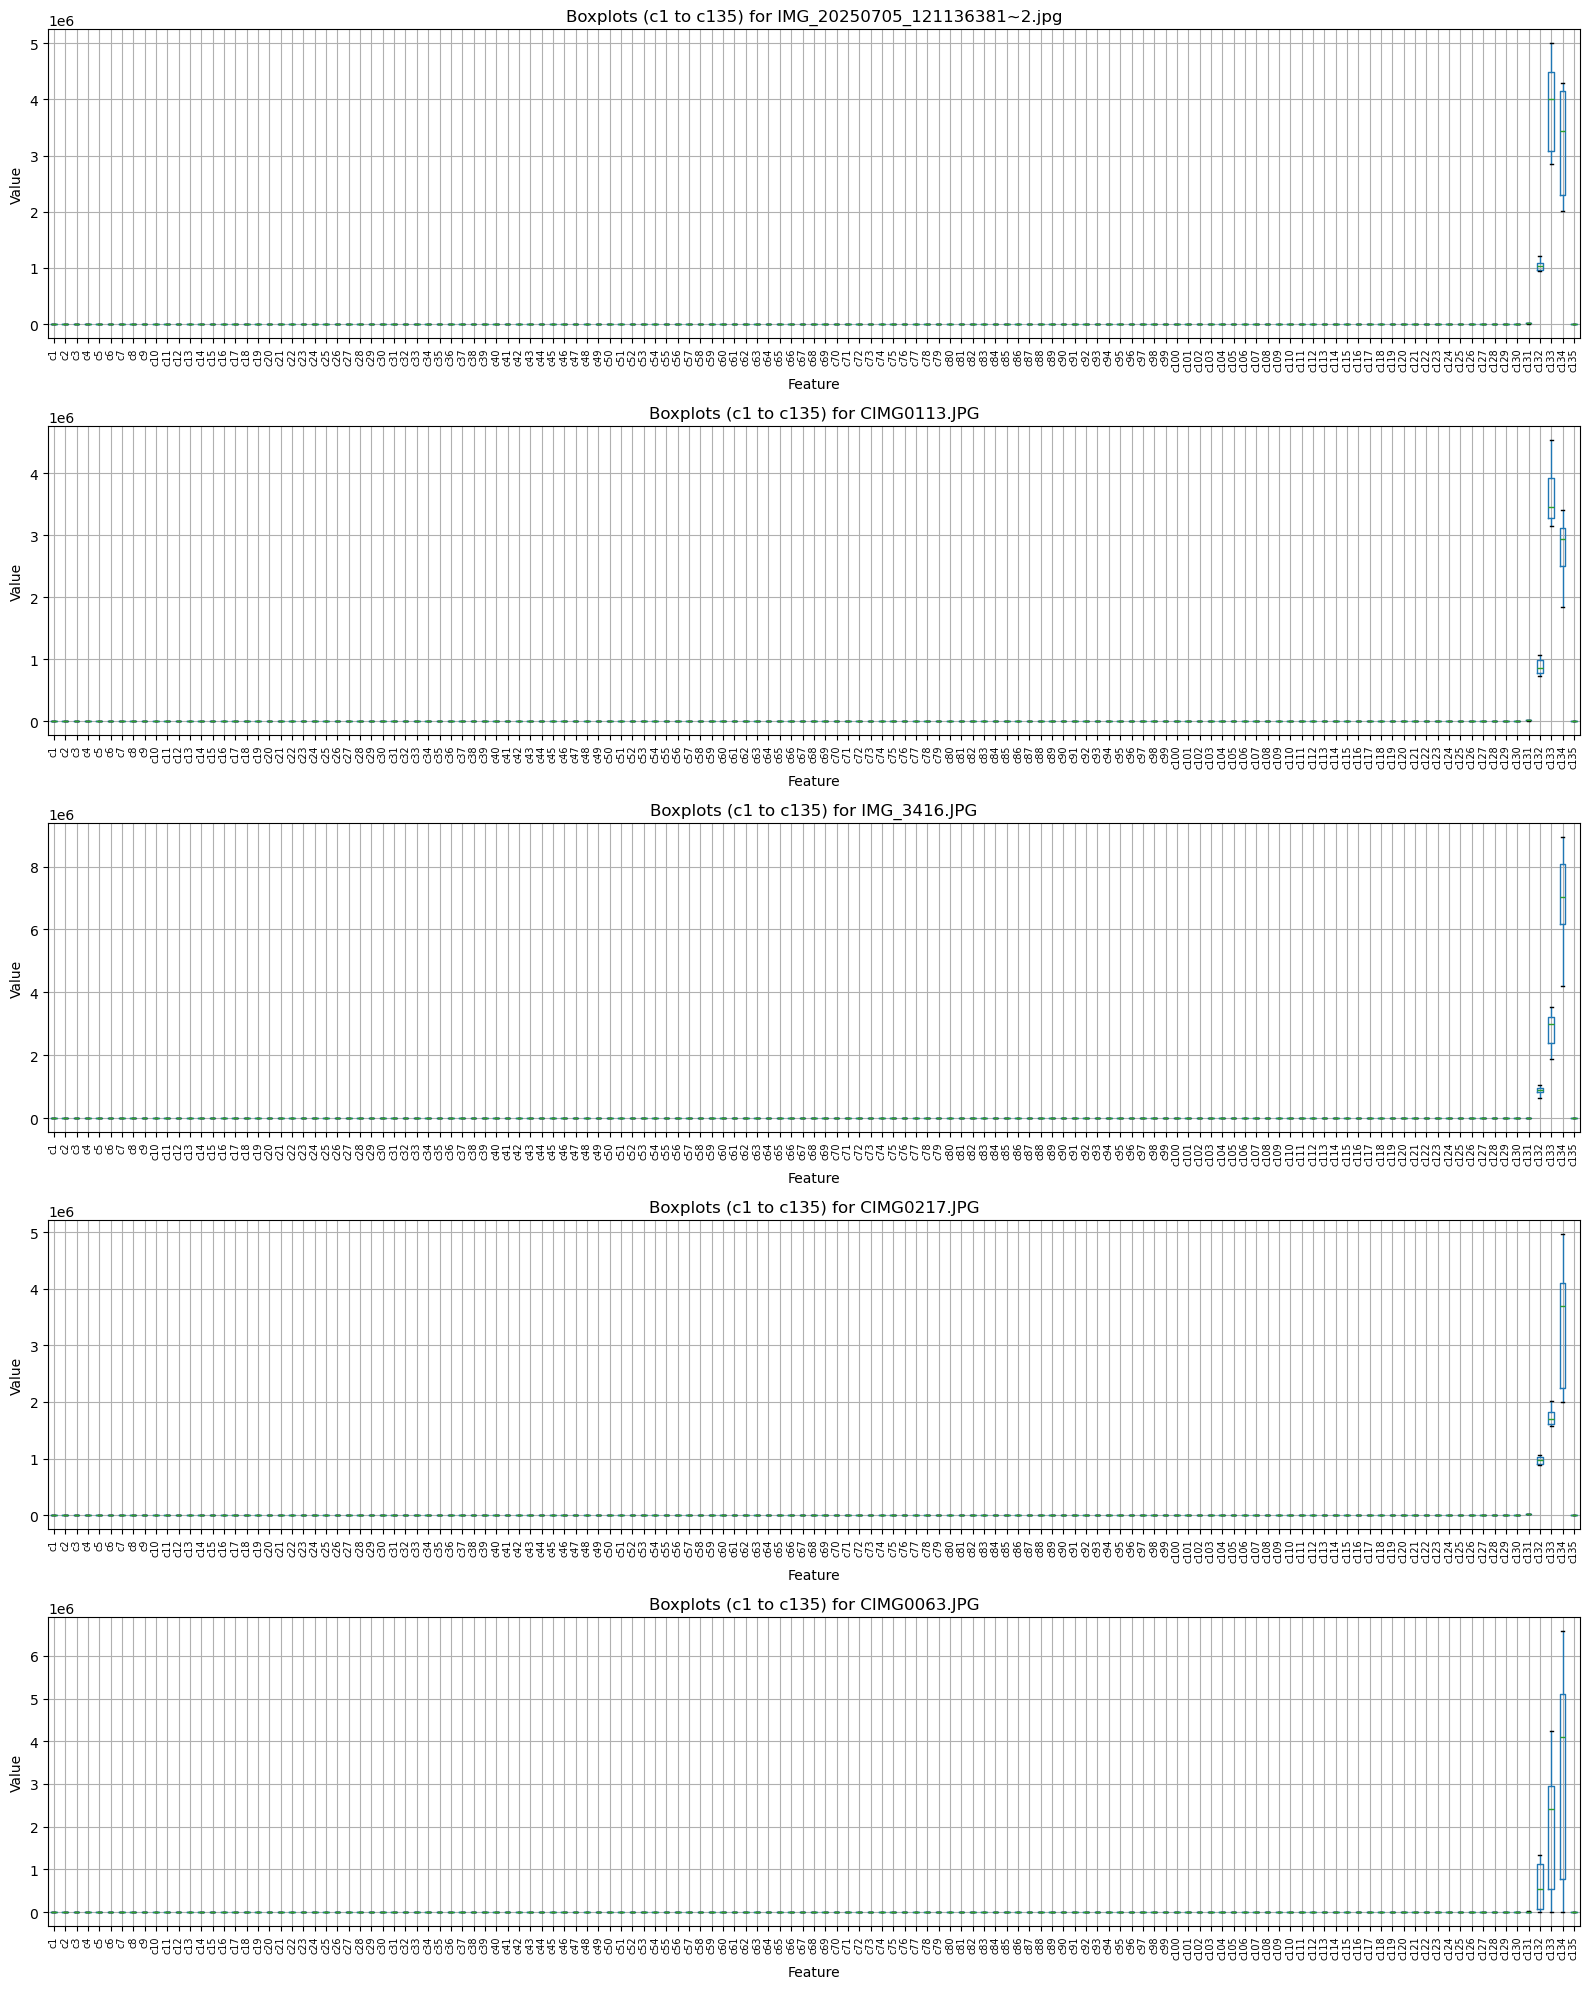

In [25]:
# ...existing code...
# Load the dataset
df = pd.read_csv("image-data-ePGD-endsem.csv")

# Group data per image with its corresponding feature variables (c1 to c135)
feature_cols = [f'c{i}' for i in range(1, 136)]
grouped_images = {img: df[df['image_filename'] == img][feature_cols + ['label']].copy() for img in df['image_filename'].unique()}

print(f"Total unique images: {len(grouped_images)}")
print("Example image name:", list(grouped_images.keys())[0])
# print("Example grouped DataFrame:\n", grouped_images[list(grouped_images.keys())[0]].head(2))

num_images = 5
selected_imgs = list(grouped_images.keys())[:num_images]

fig, axes = plt.subplots(num_images, figsize=(16, 4 * num_images))

for idx, img_name in enumerate(selected_imgs):
    img_df = grouped_images[img_name]
    # Boxplot for all feature vectors
    img_df[feature_cols].boxplot(ax=axes[idx], showfliers=False)
    axes[idx].set_title(f'Boxplots (c1 to c135) for {img_name}')
    axes[idx].set_xlabel('Feature')
    axes[idx].set_ylabel('Value')
    axes[idx].tick_params(axis='x', labelrotation=90, labelsize=7)

plt.tight_layout()
plt.show()
# ...existing code...


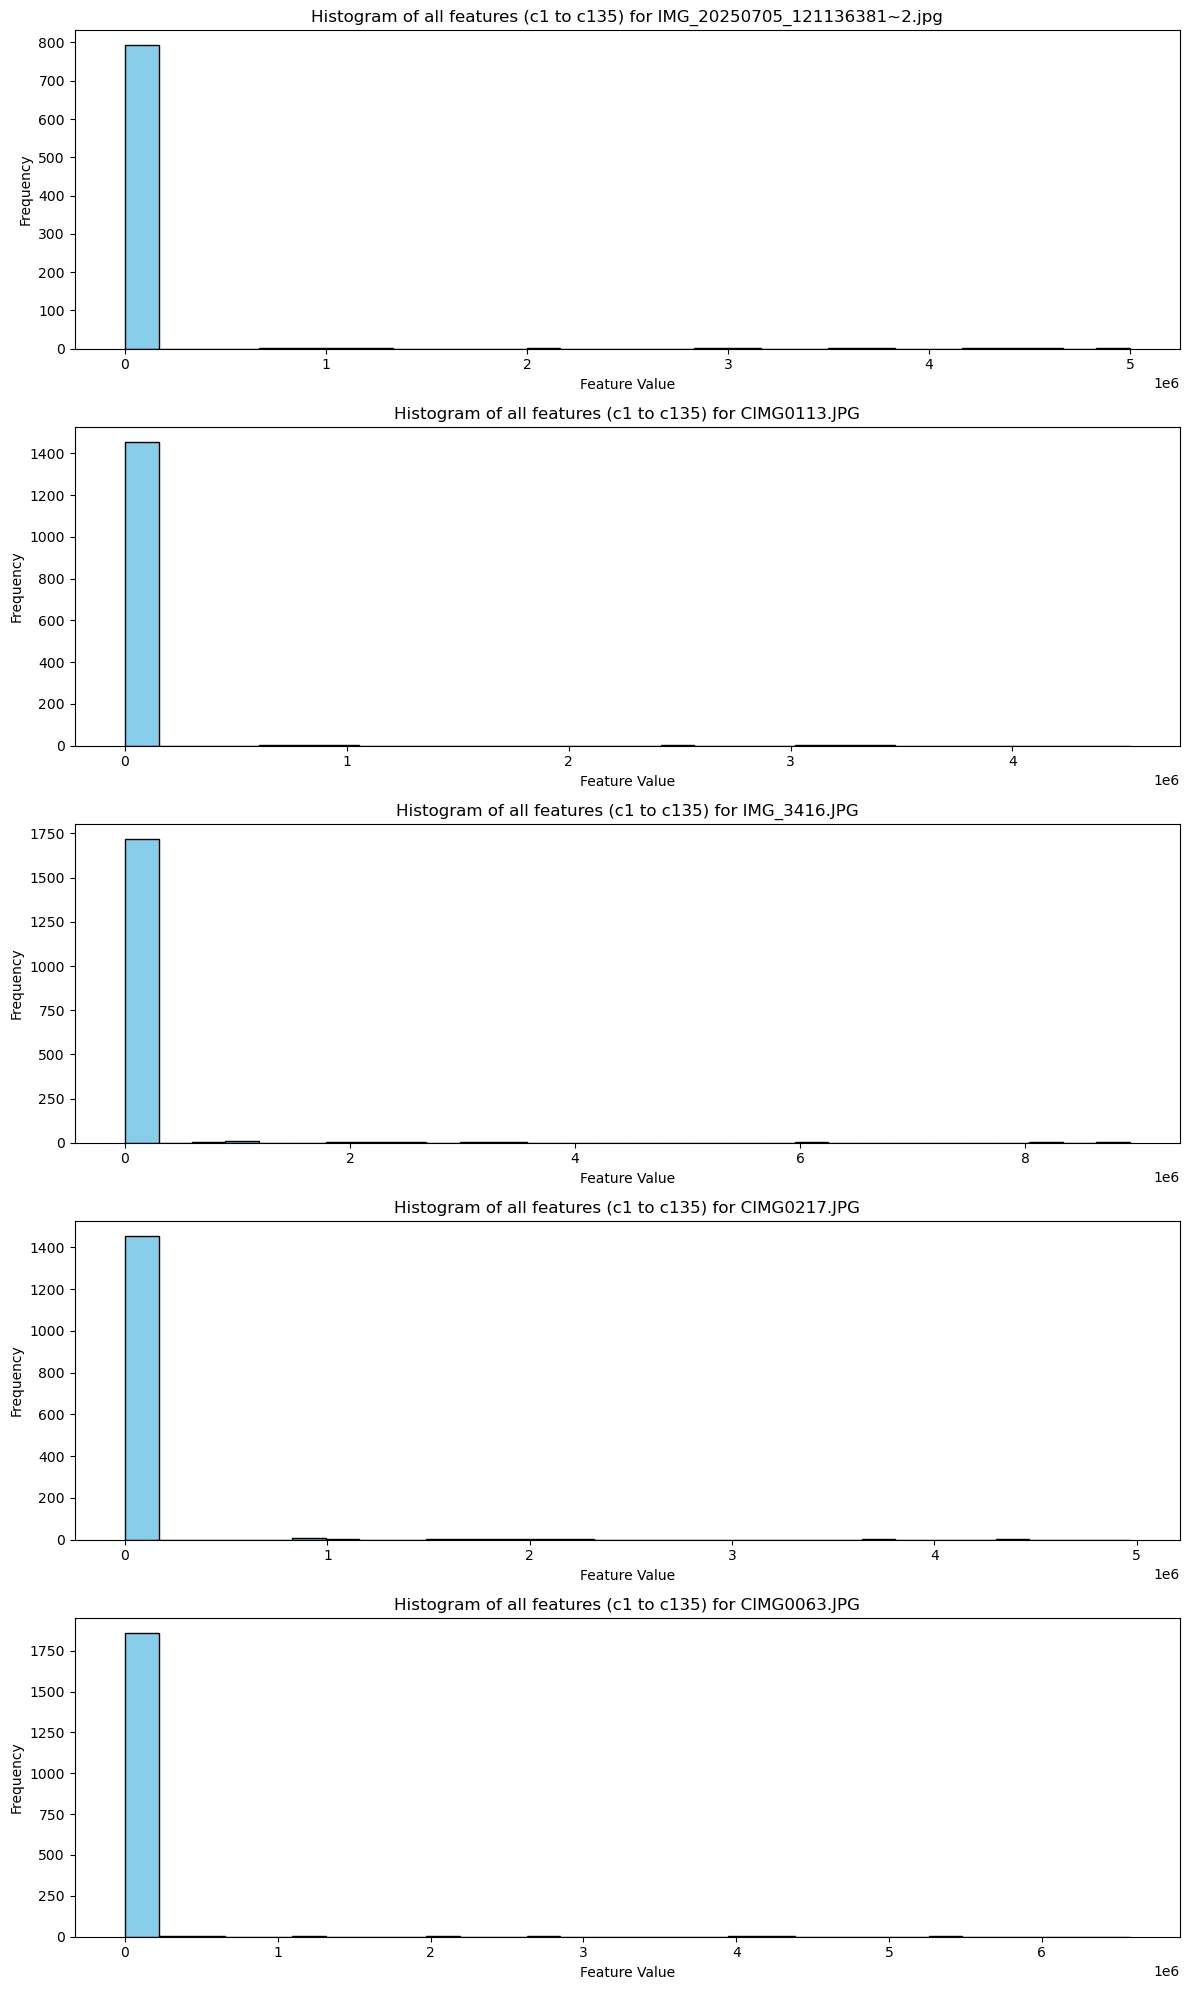

In [26]:
# ...existing code...
# Plot histogram of all features (c1 to c135) for the first 5 grouped images with subplotting

num_images = 5
selected_imgs = list(grouped_images.keys())[:num_images]

fig, axes = plt.subplots(num_images, 1, figsize=(12, 4 * num_images))

for idx, img_name in enumerate(selected_imgs):
    img_df = grouped_images[img_name]
    all_feature_values = img_df[feature_cols].values.flatten()
    axes[idx].hist(pd.Series(all_feature_values).dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Histogram of all features (c1 to c135) for {img_name}')
    axes[idx].set_xlabel('Feature Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
# ...existing code...

### Above analysis we see that

as per the above data we can see that the data of one of the image has the scaling problem and we need the data to be subjected to scaling

We would also require to reduce the number of feature and subject to dimentionality reduction 

In [28]:
# ...existing code...
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Scale and apply PCA for each grouped image
scaled_pca_images = {}

for img_name, img_df in grouped_images.items():
    # Only use feature columns for scaling and PCA
    X = df_features.values

    # Min-Max Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA (keep enough components to explain ~95% variance or set n_components as needed)
    pca = PCA(n_components=0.90, svd_solver='full')
    X_pca = pca.fit_transform(X_scaled)

    # Store results in dictionary
    scaled_pca_images[img_name] = {
        'scaled': X_scaled,
        'pca': X_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'n_components': pca.n_components_
    }

    # Example print for first image
    if img_name == list(grouped_images.keys())[0]:
        print(f"PCA for {img_name}:")
        print(f"Original shape: {X.shape}")
        print(f"Scaled shape: {X_scaled.shape}")
        print(f"PCA shape: {X_pca.shape}")
        print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
        print(f"Number of components: {pca.n_components_}")

PCA for IMG_20250705_121136381~2.jpg:
Original shape: (5000, 136)
Scaled shape: (5000, 136)
PCA shape: (5000, 21)
Explained variance ratio: [0.22214138 0.17197476 0.12356099 0.07690376 0.06369794 0.03770101
 0.03134964 0.0278346  0.021064   0.01855008 0.01436298 0.01416615
 0.01244118 0.01115996 0.01081225 0.00964677 0.00877722 0.00808831
 0.00765894 0.00721426 0.00669557]
Number of components: 21
